In [1]:
import numpy as np
import pandas as pd

import statsmodels.api as sm
from scipy.stats import ks_2samp, mannwhitneyu
from sklearn.metrics import average_precision_score

from tqdm.auto import tqdm

import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.pipeline import Pipeline
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import (
    average_precision_score,
    roc_auc_score, 
    precision_recall_curve,
    classification_report
)
pd.set_option("display.max_rows", None)
from statsmodels.tools.sm_exceptions import PerfectSeparationError

TARGET = "fraud"

%matplotlib inline

In [2]:
df = pd.read_parquet("../5DATA/dataset/train_stage2")

---

# 단일 value 제거

In [3]:
# 각 컬럼의 고유값 개수 계산
nunique = df.nunique(dropna=False)

# 고유값이 1개인 컬럼만 추출     
single_value_cols = nunique[nunique == 1].index.tolist()

print("단일 value 컬럼 개수:", len(single_value_cols))
print("단일 value 컬럼 목록:")
print(single_value_cols)

단일 value 컬럼 개수: 3
단일 value 컬럼 목록:
['is_online', 'err_bad_pin', 'err_bad_zipcode']


---

# TIME DATA
- tx_year
- tx_month
- tx_day
- tx_hour
- weekday


In [4]:
def time_hour_plot_split_lift(
    df,
    x_col="tx_hour",
    title="tx_hour — Count + Fraud rate (top) + Lift (bottom)",
    order=None,
    figsize=(12, 6),
    tick_labels=None,
    color_cnt="#1f77b4",
    color_rate="#d62728",
    color_lift="#2ca02c",
):
    g = df.groupby(x_col)[TARGET].agg(rate="mean", cnt="size").reset_index()

    if order is not None:
        g[x_col] = pd.Categorical(g[x_col], categories=order, ordered=True)
        g = g.sort_values(x_col)

    base = float(df[TARGET].mean())
    g["lift"] = g["rate"] / (base + 1e-12)

    x_vals = g[x_col].tolist()
    x_pos = list(range(len(x_vals)))

    fig, (ax_top, ax_bot) = plt.subplots(
        2, 1,
        figsize=figsize,
        sharex=True,
        gridspec_kw={"height_ratios": [2.2, 1.0], "hspace": 0.12}
    )

    # --- TOP: Count + Fraud rate ---
    ax_top.bar(x_pos, g["cnt"], color=color_cnt, alpha=0.30)
    ax_top.set_ylabel("Count", color=color_cnt)
    ax_top.tick_params(axis="y", colors=color_cnt)

    ax_rate = ax_top.twinx()
    ax_rate.plot(x_pos, g["rate"], marker="o", linewidth=2.8, color=color_rate)
    ax_rate.axhline(base, linestyle="--", linewidth=1.1, color=color_rate, alpha=0.6)
    ax_rate.set_ylabel("Fraud rate", color=color_rate)
    ax_rate.tick_params(axis="y", colors=color_rate)

    ax_top.set_title(title)

    # --- BOTTOM: Lift ---
    ax_bot.plot(x_pos, g["lift"], marker="s", linewidth=2.2, color=color_lift)
    ax_bot.axhline(1.0, linestyle="--", linewidth=1.1, color=color_lift, alpha=0.6)
    ax_bot.set_ylabel("Lift", color=color_lift)
    ax_bot.tick_params(axis="y", colors=color_lift)
    ax_bot.set_xlabel(x_col)

    # tick label 처리
    if tick_labels is None:
        tick_labels = [str(v) for v in x_vals]

    ax_bot.set_xticks(x_pos)
    ax_bot.set_xticklabels(tick_labels)

    return fig, (ax_top, ax_bot, ax_rate), g

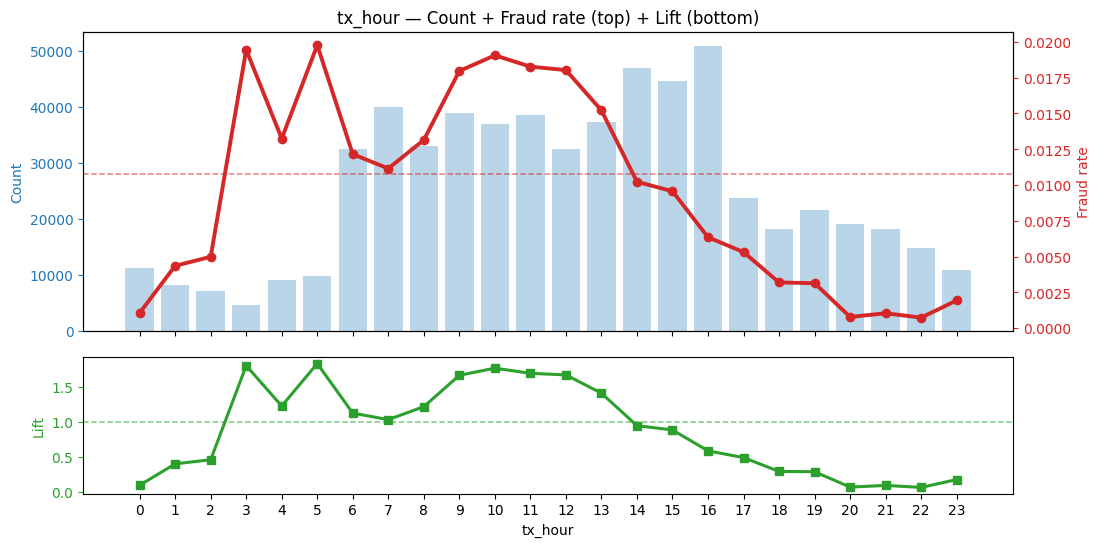

In [5]:
# hour 이중축 + lift
hour_stats = time_hour_plot_split_lift(
    df,
    x_col="tx_hour",
    order=list(range(24)),
    figsize=(12, 6),
)

> 3,5시 & 9~12시

*Lift: 해당 시간대의 사기 확률이 전체 대비 몇 배인가?

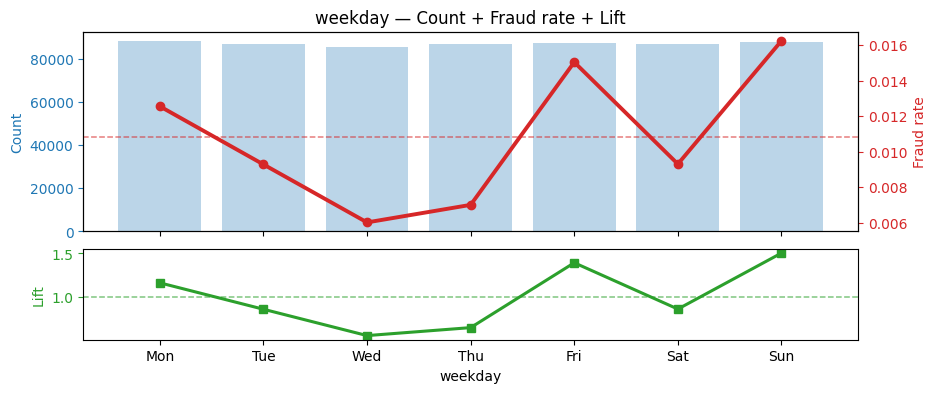

In [6]:
weekday_order = sorted(df["weekday"].dropna().unique().tolist())

weekday_stats = time_hour_plot_split_lift(
    df,
    "weekday",
    title="weekday — Count + Fraud rate + Lift",
    order=weekday_order,
    figsize=(10, 4),
)

fig = plt.gcf()

# x축 라벨이 달린(보통 맨 아래) 축만 선택
base_ax = None
for ax in fig.axes:
    if ax.get_xlabel() == "weekday":   # 너 그림에서 xlabel이 weekday로 찍힘
        base_ax = ax
        break

if base_ax is None:
    base_ax = fig.axes[-1]  # fallback: 마지막 축

weekday_labels = ["Mon", "Tue", "Wed", "Thu", "Fri", "Sat", "Sun"]

base_ax.set_xticks(weekday_order)
base_ax.set_xticklabels([weekday_labels[int(i)] for i in weekday_order])

plt.show()

> 월, 금, 일

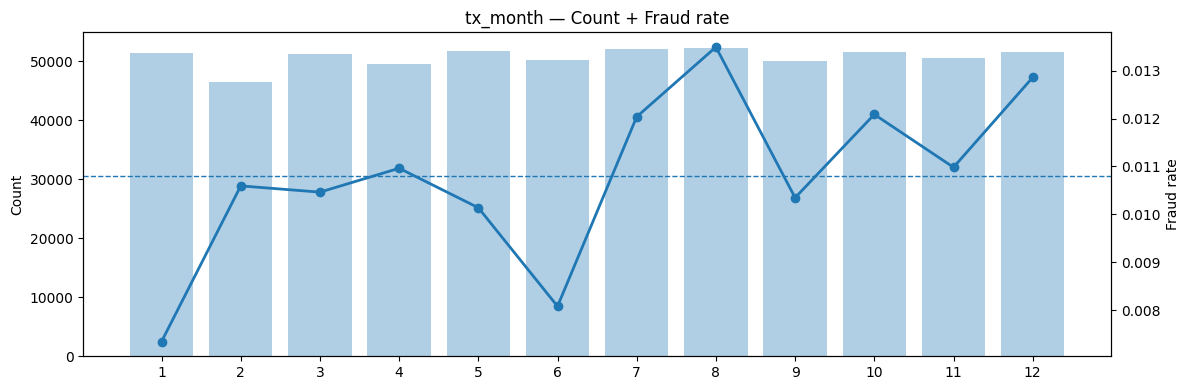

In [7]:
# month 이중축
def dual_axis_plot_no_lift(df, x_col, title=None, order=None, figsize=(10, 4)):
    g = df.groupby(x_col)[TARGET].agg(rate="mean", cnt="size").reset_index()
    if order is not None:
        g[x_col] = pd.Categorical(g[x_col], categories=order, ordered=True)
        g = g.sort_values(x_col)
    base = float(df[TARGET].mean())

    fig, ax1 = plt.subplots(figsize=figsize)
    ax1.bar(g[x_col].astype(str), g["cnt"], alpha=0.35)
    ax1.set_ylabel("Count")

    ax2 = ax1.twinx()
    ax2.plot(g[x_col].astype(str), g["rate"], marker="o", linewidth=2.0)
    ax2.axhline(base, linestyle="--", linewidth=1.0)
    ax2.set_ylabel("Fraud rate")

    ax1.set_title(title or f"{x_col}: Count + Fraud rate")
    plt.tight_layout()
    plt.show()

    return g

month_stats = dual_axis_plot_no_lift(
    df,
    "tx_month",
    title="tx_month — Count + Fraud rate",
    order=list(range(1, 13)),
    figsize=(12, 4),
)

> 7,8,10,12월

In [8]:
base_rate = df["fraud"].mean()

month_stats = (
    df.groupby("tx_month")["fraud"]
      .agg(tx_cnt="count", fraud_cnt="sum", fraud_rate="mean")
      .assign(lift=lambda x: x["fraud_rate"] / base_rate)
      .sort_index()
)

month_stats

,tx_cnt,fraud_cnt,fraud_rate,lift
tx_month,,,,
1,51452,378,0.007347,0.680561
2,46439,492,0.010595,0.981431
3,51127,535,0.010464,0.969351
4,49442,542,0.010962,1.015502
5,51780,525,0.010139,0.939236
6,50233,406,0.008082,0.748711
7,52089,627,0.012037,1.115062
8,52256,705,0.013491,1.249771
9,50059,518,0.010348,0.958573


In [9]:
# 거래량 상위달 vs lift 상위달 비교
top_volume_months = month_stats.sort_values("tx_cnt", ascending=False).head(6)
top_lift_months   = month_stats.sort_values("lift", ascending=False).head(6)

top_volume_months, top_lift_months

(          tx_cnt  fraud_cnt  fraud_rate      lift
 tx_month                                         
 8          52256        705    0.013491  1.249771
 7          52089        627    0.012037  1.115062
 5          51780        525    0.010139  0.939236
 12         51564        663    0.012858  1.191090
 10         51545        623    0.012087  1.119641
 1          51452        378    0.007347  0.680561,
           tx_cnt  fraud_cnt  fraud_rate      lift
 tx_month                                         
 8          52256        705    0.013491  1.249771
 12         51564        663    0.012858  1.191090
 10         51545        623    0.012087  1.119641
 7          52089        627    0.012037  1.115062
 11         50444        554    0.010982  1.017367
 4          49442        542    0.010962  1.015502)

거래량 거의 균등 -> fraud rate 차이

In [10]:
df["month_sin"] = np.sin(2 * np.pi * df["tx_month"] / 12).astype("float32")
df["month_cos"] = np.cos(2 * np.pi * df["tx_month"] / 12).astype("float32")

In [11]:
HIGH_RISK_MONTHS = [7,8,10,12]
df["is_risky_month"] = df["tx_month"].isin(HIGH_RISK_MONTHS).astype("int8")

In [12]:
def heatmap_rate_cnt(df, index_col, col_col, title_prefix="", index_order=None, col_order=None, figsize=(14, 5)):
    rate = df.pivot_table(index=index_col, columns=col_col, values=TARGET, aggfunc="mean")
    cnt  = df.pivot_table(index=index_col, columns=col_col, values=TARGET, aggfunc="count")

    if index_order is not None:
        rate = rate.reindex(index_order)
        cnt  = cnt.reindex(index_order)
    if col_order is not None:
        rate = rate.reindex(columns=col_order)
        cnt  = cnt.reindex(columns=col_order)

    fig, axes = plt.subplots(1, 2, figsize=figsize)

    im0 = axes[0].imshow(rate.values, aspect="auto")
    axes[0].set_title(f"{title_prefix} Fraud rate")
    axes[0].set_yticks(np.arange(rate.shape[0]))
    axes[0].set_yticklabels(rate.index.astype(str))
    axes[0].set_xticks(np.arange(rate.shape[1]))
    axes[0].set_xticklabels(rate.columns.astype(str), rotation=0)
    plt.colorbar(im0, ax=axes[0], fraction=0.046, pad=0.04)

    im1 = axes[1].imshow(cnt.values, aspect="auto")
    axes[1].set_title(f"{title_prefix} Count")
    axes[1].set_yticks(np.arange(cnt.shape[0]))
    axes[1].set_yticklabels(cnt.index.astype(str))
    axes[1].set_xticks(np.arange(cnt.shape[1]))
    axes[1].set_xticklabels(cnt.columns.astype(str), rotation=0)
    plt.colorbar(im1, ax=axes[1], fraction=0.046, pad=0.04)

    plt.tight_layout()
    plt.show()

    return rate, cnt

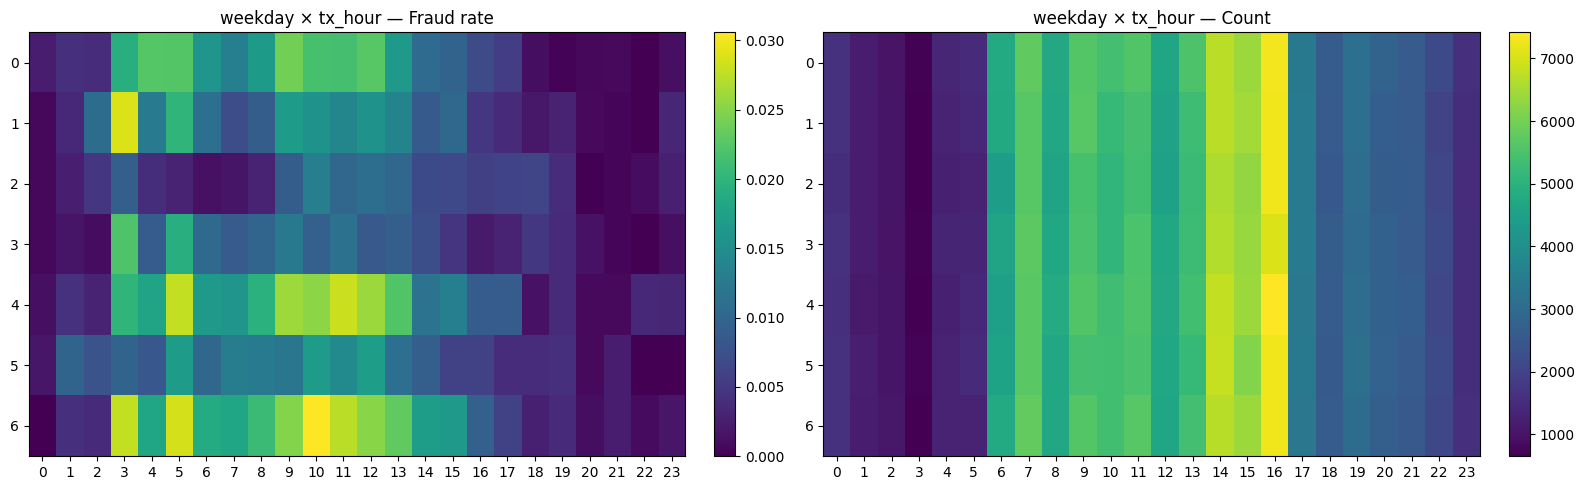

In [13]:
# weekday × hour 히트맵
weekday_order = sorted(df["weekday"].dropna().unique().tolist())
hour_order = list(range(24))

wh_rate, wh_cnt = heatmap_rate_cnt(
    df,
    index_col="weekday",
    col_col="tx_hour",
    title_prefix="weekday × tx_hour —",
    index_order=weekday_order,
    col_order=hour_order,
    figsize=(16, 5),
)

> 요일 x 시간 interacton 존재

In [14]:
pivot_rate = df.pivot_table(
    index="weekday", columns="tx_hour", values="fraud", aggfunc="mean"
)

max_idx = pivot_rate.stack().idxmax()
max_rate = float(pivot_rate.loc[max_idx[0], max_idx[1]])
max_lift = max_rate / base_rate

max_idx, max_rate, max_lift

((np.int8(6), np.int8(10)),
 0.030579899310087637,
 np.float64(2.832784430151739))

In [15]:
TOPN = 10
top_cells = pivot_rate.stack().sort_values(ascending=False).head(TOPN)
top_pairs = list(top_cells.index)  # [(weekday, hour), ...]

top_pairs[:10], top_cells.head(10)

([(6, 10),
  (1, 3),
  (6, 5),
  (4, 11),
  (4, 5),
  (6, 3),
  (6, 11),
  (4, 9),
  (4, 12),
  (4, 10)],
 weekday  tx_hour
 6        10         0.030580
 1        3          0.028963
 6        5          0.028636
 4        11         0.028083
          5          0.027816
 6        3          0.027735
          11         0.027414
 4        9          0.026109
          12         0.025955
          10         0.025248
 dtype: float64)

In [16]:
top_pair_set = set(top_pairs)
df["is_risky_wd_hour"] = [
    int((wd, hr) in top_pair_set)
    for wd, hr in zip(df["weekday"], df["tx_hour"])
]
df["is_risky_wd_hour"] = df["is_risky_wd_hour"].astype("int8")

df.groupby("is_risky_wd_hour")["fraud"].mean(), float(df[df["is_risky_wd_hour"]==1]["fraud"].mean()/base_rate)

(is_risky_wd_hour
 0    0.009743
 1    0.027368
 Name: fraud, dtype: float64,
 2.5352338229139275)

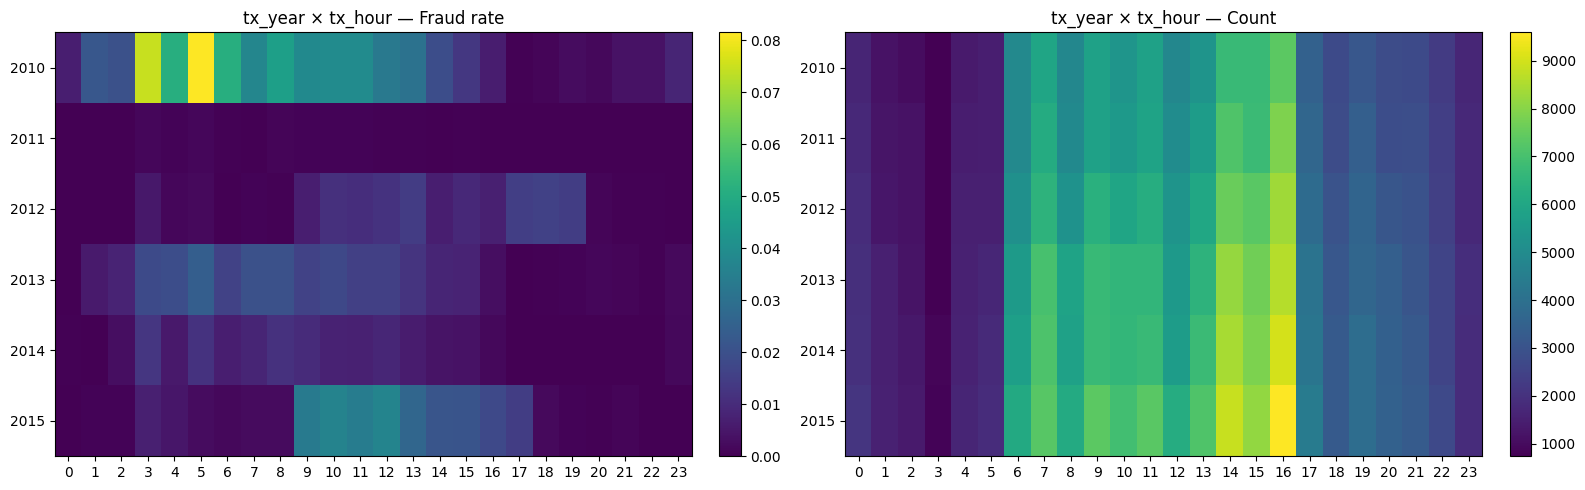

In [17]:
# year × hour 히트맵
year_order = sorted(df["tx_year"].dropna().unique().tolist())
yh_rate, yh_cnt = heatmap_rate_cnt(
    df,
    index_col="tx_year",
    col_col="tx_hour",
    title_prefix="tx_year × tx_hour —",
    index_order=year_order,
    col_order=hour_order,
    figsize=(16, 5),
)

In [18]:
# 2011년 데이터 실제로 얼마나 있는지
print(df[df['tx_year']==2011]['fraud'].value_counts())
print(df[df['tx_year']==2011]['fraud'].mean())  # 실제 fraud rate

# 다른 연도와 비교
df.groupby('tx_year')['fraud'].agg(['mean','count','sum'])

fraud
0    93207
1       35
Name: count, dtype: int64
0.00037536732373822957


,mean,count,sum
tx_year,,,
2010,0.025683,89944,2310
2011,0.000375,93242,35
2012,0.006975,98782,689
2013,0.010634,105227,1119
2014,0.005212,107831,562
2015,0.016340,113404,1853


**2010**:

3~5시 구간에서 rate 8% 이상 (비정상적으로 높음)

초반 데이터 품질 또는 공격 패턴 다름

**2011**:

거의 0 근접
→ suspicious
→ 라벨 누락 가능성

**2012**:

10~17시 구간 상승

**2015**:

9~12시 구간에서 뚜렷한 상승

*=> 시간적 drift*
> hour 자체의 risk가 고정된 것이 아니라\
> year에 따라 conditional risk가 변한다.



**Drift 대응 전략**
- sample_weight, sliding window

In [19]:
import numpy as np
import pandas as pd
import lightgbm as lgb
from sklearn.metrics import roc_auc_score, average_precision_score

TARGET = "fraud"

def _year_weights(year_series, alpha=0.8):
    y = year_series.to_numpy().astype(int)
    y_max = int(np.max(y))
    return np.exp(alpha * (y - y_max)).astype(float)

def _fit_eval(df_tr, df_te, feature_cols, use_weight=False, weight_alpha=0.8, seed=42):
    X_tr = df_tr[feature_cols]
    y_tr = df_tr[TARGET].astype(int).to_numpy()
    X_te = df_te[feature_cols]
    y_te = df_te[TARGET].astype(int).to_numpy()

    w_tr = _year_weights(df_tr["tx_year"], alpha=weight_alpha) if use_weight else None

    clf = lgb.LGBMClassifier(
        objective="binary",
        n_estimators=4000,
        learning_rate=0.03,
        num_leaves=64,
        min_child_samples=200,
        subsample=0.8,
        colsample_bytree=0.8,
        reg_lambda=1.0,
        random_state=seed,
        n_jobs=-1,
    )

    clf.fit(
        X_tr, y_tr,
        sample_weight=w_tr,
        eval_set=[(X_te, y_te)],
        eval_metric="auc",
        callbacks=[lgb.early_stopping(200, verbose=False)],
    )

    s_te = clf.predict_proba(X_te)[:, 1]
    return {
        "n_train": int(len(df_tr)),
        "n_test": int(len(df_te)),
        "pos_rate_train": float(y_tr.mean()),
        "pos_rate_test": float(y_te.mean()),
        "ROC_AUC": float(roc_auc_score(y_te, s_te)),
        "PR_AUC": float(average_precision_score(y_te, s_te)),
        "best_iter": int(getattr(clf, "best_iteration_", clf.n_estimators)),
    }

def compare_3ways_on_df(df, feature_cols, weight_alpha=0.8):
    years = sorted(df["tx_year"].dropna().unique().astype(int).tolist())
    assert years[0] == 2010 and years[-1] == 2015, years

    train_years_all = [2010, 2011, 2012, 2013, 2014]
    test_years = [2015]

    df_tr_all = df[df["tx_year"].isin(train_years_all)].copy()
    df_te = df[df["tx_year"].isin(test_years)].copy()

    recent_k = 4
    train_years_recent = [2011, 2012, 2013, 2014]
    df_tr_recent = df[df["tx_year"].isin(train_years_recent)].copy()

    rows = []
    rows.append({"tag": "2010-2014_no_weight", **_fit_eval(df_tr_all, df_te, feature_cols, use_weight=False)})
    rows.append({"tag": f"2010-2014_weight(alpha={weight_alpha})", **_fit_eval(df_tr_all, df_te, feature_cols, use_weight=True, weight_alpha=weight_alpha)})
    rows.append({"tag": "2011-2014_recent4y_no_weight", **_fit_eval(df_tr_recent, df_te, feature_cols, use_weight=False)})

    return pd.DataFrame(rows).sort_values(["PR_AUC", "ROC_AUC"], ascending=False).reset_index(drop=True)

import numpy as np

TARGET = "fraud"

feature_cols = (
    df
    .select_dtypes(include=[np.number])
    .columns
    .drop([TARGET], errors="ignore")
    .tolist()
)

res = compare_3ways_on_df(df, feature_cols, weight_alpha=0.8)
res

[LightGBM] [Info] Number of positive: 4715, number of negative: 490311
[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.013177 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 5512
[LightGBM] [Info] Number of data points in the train set: 495026, number of used features: 53
[LightGBM] [Info] [binary:BoostFromScore]: pavg=0.009525 -> initscore=-4.644291
[LightGBM] [Info] Start training from score -4.644291
[LightGBM] [Info] Number of positive: 4715, number of negative: 490311
[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.015740 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 5512
[LightGBM] [Info] Number of data points in the train set: 495026, number of used features: 53
[LightGBM] [Info

,tag,n_train,n_test,pos_rate_train,pos_rate_test,ROC_AUC,PR_AUC,best_iter
0,2010-2014_no_weight,495026,113404,0.009525,0.01634,0.913509,0.340996,20
1,2011-2014_recent4y_no_weight,405082,113404,0.005937,0.01634,0.871044,0.324647,8
2,2010-2014_weight(alpha=0.8),495026,113404,0.009525,0.01634,0.812198,0.296268,8


> drift가 존재하긴 하지만\
> 오래된 데이터가 노이즈는 아니다.

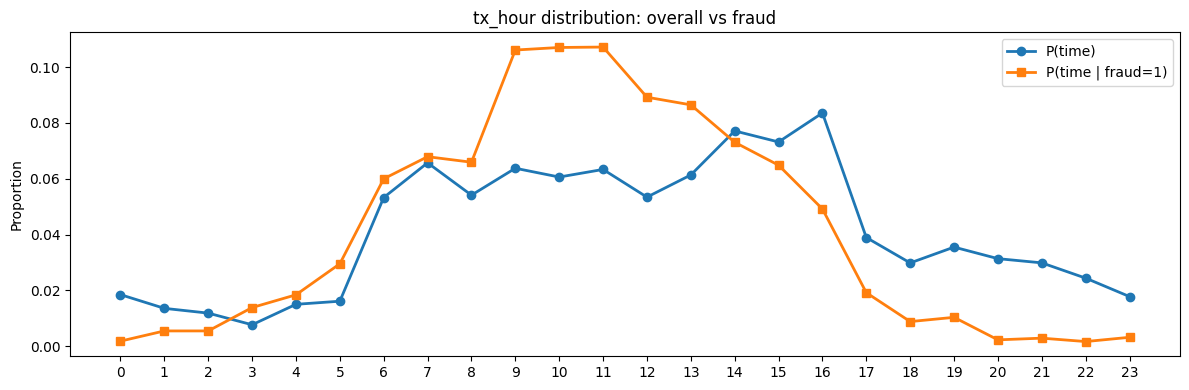

In [20]:
# distribution 비교 (전체 vs fraud)
def plot_distribution_compare(df, time_col, order=None, figsize=(12, 4)):
    sub = df[[time_col, TARGET]].dropna()
    all_cnt = sub[time_col].value_counts(normalize=True)
    fraud_cnt = sub.loc[sub[TARGET] == 1, time_col].value_counts(normalize=True)

    if order is not None:
        all_cnt = all_cnt.reindex(order).fillna(0)
        fraud_cnt = fraud_cnt.reindex(order).fillna(0)
    else:
        idx = sorted(all_cnt.index.tolist())
        all_cnt = all_cnt.reindex(idx).fillna(0)
        fraud_cnt = fraud_cnt.reindex(idx).fillna(0)

    x = np.arange(len(all_cnt.index))
    fig, ax = plt.subplots(figsize=figsize)
    ax.plot(x, all_cnt.values, marker="o", linewidth=2.0, label="P(time)")
    ax.plot(x, fraud_cnt.values, marker="s", linewidth=2.0, label="P(time | fraud=1)")
    ax.set_xticks(x)
    ax.set_xticklabels([str(v) for v in all_cnt.index], rotation=0)
    ax.set_ylabel("Proportion")
    ax.set_title(f"{time_col} distribution: overall vs fraud")
    ax.legend()
    plt.tight_layout()
    plt.show()

    out = pd.DataFrame({"p_all": all_cnt.values, "p_fraud": fraud_cnt.values}, index=all_cnt.index)
    return out

dist_hour = plot_distribution_compare(df, "tx_hour", order=list(range(24)), figsize=(12, 4))

**Lift 그래프 → 임계치 아티팩트(is_risky_hour)로 연결**

In [21]:
hour_stats = (
    df.groupby("tx_hour")["fraud"]
      .agg(tx_cnt="count", fraud_rate="mean")
      .assign(lift=lambda x: x["fraud_rate"] / base_rate)
      .sort_values("lift", ascending=False)
)

hour_stats.head(10)

,tx_cnt,fraud_rate,lift
tx_hour,,,
5,9814,0.019768,1.831189
3,4679,0.019449,1.801631
10,36881,0.019061,1.765754
11,38536,0.018269,1.692324
12,32503,0.018029,1.670135
9,38797,0.017965,1.664225
13,37335,0.015214,1.409320
4,9136,0.013244,1.226893
8,32933,0.013148,1.217963


In [22]:
RISKY_HOURS = [3, 4, 5, 9, 10, 11, 12]
df['is_risky_hour'] = df['tx_hour'].isin(RISKY_HOURS).astype('int8')
df.groupby('is_risky_hour')['fraud'].mean() 

is_risky_hour
0    0.007925
1    0.018175
Name: fraud, dtype: float64

In [23]:
RISKY_HOURS = [3, 5, 9, 10, 11]
df['is_risky_hour'] = df['tx_hour'].isin(RISKY_HOURS).astype('int8')
df.groupby('is_risky_hour')['fraud'].mean() 

is_risky_hour
0    0.008711
1    0.018562
Name: fraud, dtype: float64

In [24]:
RISKY_HOURS = [3, 5, 10, 11]
df['is_risky_hour'] = df['tx_hour'].isin(RISKY_HOURS).astype('int8')
df.groupby('is_risky_hour')['fraud'].mean() 

is_risky_hour
0    0.009404
1    0.018819
Name: fraud, dtype: float64

In [25]:
RISKY_HOURS = [3, 5, 10]
df['is_risky_hour'] = df['tx_hour'].isin(RISKY_HOURS).astype('int8')
df.groupby('is_risky_hour')['fraud'].mean() 

is_risky_hour
0    0.010017
1    0.019232
Name: fraud, dtype: float64

In [26]:
RISKY_HOURS = [3, 5]
df['is_risky_hour'] = df['tx_hour'].isin(RISKY_HOURS).astype('int8')
df.groupby('is_risky_hour')['fraud'].mean() 

is_risky_hour
0    0.010579
1    0.019665
Name: fraud, dtype: float64

In [27]:
# drift 수치화 (PSI / CV)
def psi_from_counts(ref_pct, cur_pct, eps=1e-12):
    r = np.asarray(ref_pct, dtype=float) + eps
    c = np.asarray(cur_pct, dtype=float) + eps
    return float(np.sum((c - r) * np.log(c / r)))

def psi_categorical(df_ref, df_cur, col, order=None):
    ref = df_ref[col].value_counts(normalize=True)
    cur = df_cur[col].value_counts(normalize=True)
    if order is None:
        order = sorted(set(ref.index).union(set(cur.index)))
    ref = ref.reindex(order).fillna(0.0)
    cur = cur.reindex(order).fillna(0.0)
    return psi_from_counts(ref.values, cur.values), pd.DataFrame({"ref": ref.values, "cur": cur.values}, index=order)

def cv_lift_by_year(df, time_col, order=None, year_col="tx_year"):
    years = sorted(df[year_col].dropna().unique().tolist())
    rows = []
    for y in years:
        sub = df[df[year_col] == y]
        base = float(sub[TARGET].mean())
        g = sub.groupby(time_col)[TARGET].agg(rate="mean", cnt="size").reset_index()
        if order is not None:
            g[time_col] = pd.Categorical(g[time_col], categories=order, ordered=True)
            g = g.sort_values(time_col)
        g["lift"] = g["rate"] / (base + 1e-12)
        rows.append(g.set_index(time_col)["lift"].rename(y))
    lift_mat = pd.concat(rows, axis=1)
    cv = lift_mat.std(axis=1) / (lift_mat.mean(axis=1).abs() + 1e-12)
    out = lift_mat.copy()
    out["cv"] = cv
    return out

train_years = sorted(df["tx_year"].unique().tolist())
split_year = np.median(train_years)
df_ref = df[df["tx_year"] <= split_year]
df_cur = df[df["tx_year"] > split_year]

psi_hour, hour_refcur = psi_categorical(df_ref, df_cur, "tx_hour", order=list(range(24)))
psi_weekday, weekday_refcur = psi_categorical(df_ref, df_cur, "weekday", order=sorted(df["weekday"].unique().tolist()))

lift_cv_hour = cv_lift_by_year(df, "tx_hour", order=list(range(24)), year_col="tx_year")

print("PSI(tx_hour):", round(psi_hour, 4))
print("PSI(weekday):", round(psi_weekday, 4))
display(lift_cv_hour.sort_values("cv", ascending=False).head(10))

PSI(tx_hour): 0.0007
PSI(weekday): 0.0006


,2010,2011,2012,2013,2014,2015,cv
tx_hour,,,,,,,
18,0.042678,0.0,2.255152,0.029958,0.000000,0.131492,2.208660
19,0.111531,0.0,2.109555,0.077396,0.000000,0.047113,2.156581
0,0.261800,0.0,0.000000,0.000000,0.098294,0.000000,1.772633
17,0.022403,0.0,2.165486,0.000000,0.000000,0.911169,1.714133
1,0.861580,0.0,0.000000,0.557162,0.000000,0.039231,1.539814
22,0.154375,0.0,0.059146,0.036906,0.000000,0.000000,1.447082
23,0.322936,0.0,0.000000,0.199125,0.307813,0.000000,1.138150
2,0.792319,0.0,0.000000,0.771424,0.594485,0.044967,1.068212
20,0.069654,0.0,0.137900,0.137803,0.000000,0.035183,0.996212


**PSI = Σ (cur - ref) * log(cur / ref)**
: 분포 차이 측정 지표

- 0에 가까우면 거의 동일 분포

> 거래 시간 분포 자체는 거의 안 바뀜

-  연도별 CV(lift) 계산하고 그 lift가 연도별로 얼마나 변했는지 CV = std/mean로 측정

> CV > 1: 연도마다 lift 크게 흔들림

**2011 이상 현상 발견**

In [28]:
year_stats = (
    df.groupby("tx_year")["fraud"]
      .agg(count="count", sum="sum", mean="mean")
      .sort_index()
)
year_stats

,count,sum,mean
tx_year,,,
2010,89944,2310,0.025683
2011,93242,35,0.000375
2012,98782,689,0.006975
2013,105227,1119,0.010634
2014,107831,562,0.005212
2015,113404,1853,0.016340


In [29]:
# 2011만 따로 확인
df_2011 = df[df["tx_year"] == 2011]
df_2011["fraud"].value_counts(dropna=False), float(df_2011["fraud"].mean()), len(df_2011)

(fraud
 0    93207
 1       35
 Name: count, dtype: int64,
 0.00037536732373822957,
 93242)

In [30]:
df = df[df["tx_year"] != 2011].copy()

In [31]:
print(f'2011 제거 후 fraud rate: {df["fraud"].mean():.4%}')  

2011 제거 후 fraud rate: 1.2681%


In [32]:
# 고위험 시간대 Top5 + 거래량 포함 표 (hour 기준)
def topk_risky_bins(df, time_col, k=5, min_cnt=50):
    base = float(df[TARGET].mean())
    g = df.groupby(time_col)[TARGET].agg(rate="mean", cnt="size", fraud_cnt="sum").reset_index()
    g["lift"] = g["rate"] / (base + 1e-12)
    g = g[g["cnt"] >= min_cnt].copy()
    g["cnt_share"] = g["cnt"] / g["cnt"].sum()
    g["fraud_share"] = g["fraud_cnt"] / (g["fraud_cnt"].sum() + 1e-12)
    g = g.sort_values(["lift", "cnt"], ascending=[False, False]).head(k)
    return g

top5_hour = topk_risky_bins(df, "tx_hour", k=5, min_cnt=50)
display(top5_hour)

,tx_hour,rate,cnt,fraud_cnt,lift,cnt_share,fraud_share
5,5,0.023041,8333,192,1.816992,0.016175,0.029389
3,3,0.022895,3931,90,1.805479,0.007630,0.013776
10,10,0.022275,31380,699,1.756618,0.060910,0.106995
11,11,0.021399,32665,699,1.687515,0.063404,0.106995
12,12,0.021257,27473,584,1.676331,0.053326,0.089392


- 전체 기간 통합했을 때 위험 시간대

3~5시

10~12시

는 평균적으로 baseline보다 1.7~1.8배 위험

-> Covariate drift 없음 (PSI ≈ 0)\
-> Conditional drift 일부 존재 (CV 높음 구간 있음)\
-> 하지만 모델 성능에는 치명적 영향 없음


따라서 지금 단계에서

- sliding window 필요 없음
- aggressive weighting 필요 없음

> hour) 3~5, 10~12\
> weekday) hour이랑 interaction 존재, 토_일_월\
> month) 7,8,10\
> year) drift 존재 but 무시 가능


In [33]:
df["hour_sin"] = np.sin(2 * np.pi * df["tx_hour"] / 24).astype("float32")
df["hour_cos"] = np.cos(2 * np.pi * df["tx_hour"] / 24).astype("float32")

In [34]:
import numpy as np
import pandas as pd
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import average_precision_score
from sklearn.model_selection import train_test_split

LABEL = "fraud"

X = df[["tx_hour", "hour_sin", "hour_cos"]].copy()
y = df[LABEL].astype(int)

X_train, X_valid, y_train, y_valid = train_test_split(
    X, y, test_size=0.3, random_state=42, stratify=y
)

# 후보 조합
cands = {
    "raw_hour_only": ["tx_hour"],
    "sin_only": ["hour_sin"],
    "cos_only": ["hour_cos"],
    "sin_cos": ["hour_sin", "hour_cos"],
}

rows = []

for tag, cols in cands.items():
    clf = LogisticRegression(max_iter=1000)
    clf.fit(X_train[cols], y_train)

    pred = clf.predict_proba(X_valid[cols])[:, 1]
    prauc = average_precision_score(y_valid, pred)

    rows.append({
        "tag": tag,
        "cols": cols,
        "PR_AUC": prauc
    })

pd.DataFrame(rows).sort_values("PR_AUC", ascending=False)

,tag,cols,PR_AUC
3,sin_cos,"[hour_sin, hour_cos]",0.019444
2,cos_only,[hour_cos],0.017845
1,sin_only,[hour_sin],0.016167
0,raw_hour_only,[tx_hour],0.015102


> raw hour는 선형적 표현으로 주기 구조를 담지 못한다.\
> cyclic encoding이 성능 및 통계적으로 우수하므로 raw를 제거한다.

In [35]:
results = []

for col in ["tx_year",
            "tx_month",
            "tx_day",
            "tx_hour",
            "weekday",
            "hour_sin",
            "hour_cos",
            "month_sin",
            "month_cos",
            "is_risky_month"]:

    X = sm.add_constant(df[[col]].dropna())
    y = df.loc[X.index, "fraud"]

    model = sm.Logit(y, X).fit(disp=0)

    coef = model.params[col]
    pval = model.pvalues[col]
    or_val = np.exp(coef)

    results.append([col, coef, or_val, pval])

pd.DataFrame(results, columns=["feature","coef","OR","p_value"])

,feature,coef,OR,p_value
0,tx_year,-0.151343,0.859553,1.541298e-101
1,tx_month,0.031782,1.032293,2.113122e-18
2,tx_day,0.005308,1.005322,1.757110e-04
3,tx_hour,-0.056449,0.945114,1.131595e-128
4,weekday,0.068347,1.070736,6.690350e-28
5,hour_sin,0.505366,1.657593,1.038672e-175
6,hour_cos,-0.827559,0.437115,7.217021e-213
7,month_sin,-0.105827,0.899580,2.302304e-09
8,month_cos,-0.001216,0.998785,9.447974e-01
9,is_risky_month,0.260256,1.297262,1.334371e-24


In [36]:
BASELINE = [
    # 거래 강도
    "log_abs_amount",
    "amount_income_ratio",
    "amount_limit_ratio",

    # 에러
    "has_error",

    # 고객 맥락 최소
    "credit_limit",
    "current_age",

    # 카드 특성
    "is_credit",
    "has_chip",
]

In [37]:
TIME_CANDIDATES = ["tx_year",
            "tx_month",
            "tx_day",
            "tx_hour",
            "weekday",
            "hour_sin",
            "hour_cos",
            "month_sin",
            "month_cos",
            "is_risky_month"]
LABEL = "fraud"

# 1) 유틸: 모델 학습 + 점수
def fit_logit_and_score(df, features, y_col=LABEL):
    use_cols = features + [y_col]
    tmp = df[use_cols].dropna(subset=use_cols).copy()

    X = sm.add_constant(tmp[features], has_constant="add")
    y = tmp[y_col].astype(int)

    X = X.apply(pd.to_numeric, errors="raise")

    model = sm.Logit(y, X).fit(disp=0)
    score = model.predict(X)
    return model, y, score

def top_decile_lift(y_true, score, q=0.90):
    y_true = pd.Series(y_true).astype(int)
    score = pd.Series(score)

    base_rate = y_true.mean()
    thr = score.quantile(q)

    top_mask = score >= thr
    top_rate = y_true[top_mask].mean()
    lift = top_rate / base_rate if base_rate > 0 else np.nan

    return {
        "base_rate": float(base_rate),
        "top_decile_rate": float(top_rate),
        "top_decile_lift": float(lift),
        "thr": float(thr),
        "top_n": int(top_mask.sum()),
    }

# 2) Baseline 고정 성능
base_model, y_base, s_base = fit_logit_and_score(df, BASELINE, y_col=LABEL)
base_lift = top_decile_lift(y_base, s_base)

print("=== BASELINE ===")
print(base_lift)

# 3) 시간 피처 add-one 다변량 검증
rows = []

for tcol in TIME_CANDIDATES:
    feats = BASELINE + [tcol]

    model, y_aligned, score = fit_logit_and_score(df, feats, y_col=LABEL)
    lift = top_decile_lift(y_aligned, score)

    # 추가된 피처의 coef/OR/p-value만 뽑기
    coef = model.params.get(tcol, np.nan)
    pval = model.pvalues.get(tcol, np.nan)
    or_val = float(np.exp(coef)) if pd.notnull(coef) else np.nan

    # baseline 대비 lift 개선량
    delta_lift = lift["top_decile_lift"] - base_lift["top_decile_lift"]
    delta_rate = lift["top_decile_rate"] - base_lift["top_decile_rate"]

    rows.append({
        "added_time_feature": tcol,
        "coef": float(coef) if pd.notnull(coef) else np.nan,
        "OR": or_val,
        "p_value": float(pval) if pd.notnull(pval) else np.nan,
        "base_rate": lift["base_rate"],
        "top_decile_rate": lift["top_decile_rate"],
        "top_decile_lift": lift["top_decile_lift"],
        "delta_top_rate_vs_baseline": delta_rate,
        "delta_lift_vs_baseline": delta_lift,
        "top_n": lift["top_n"],
    })

inc_df = (
    pd.DataFrame(rows)
      .sort_values("delta_lift_vs_baseline", ascending=False)
      .reset_index(drop=True)
)

display(inc_df)


=== BASELINE ===
{'base_rate': 0.012680807782789972, 'top_decile_rate': 0.04941866107649605, 'top_decile_lift': 3.8971224801282482, 'thr': 0.023932375490811033, 'top_n': 51519}


,added_time_feature,coef,OR,p_value,base_rate,top_decile_rate,top_decile_lift,delta_top_rate_vs_baseline,delta_lift_vs_baseline,top_n
0,hour_cos,-0.871794,0.418200,1.567515e-239,0.012681,0.053689,4.233873,0.004270,0.336751,51519
1,hour_sin,0.525900,1.691981,3.265919e-181,0.012681,0.053165,4.192545,0.003746,0.295422,51519
2,tx_hour,-0.056385,0.945176,4.225990e-129,0.012681,0.051030,4.024169,0.001611,0.127047,51519
3,tx_year,-0.146534,0.863696,4.812875e-93,0.012681,0.050797,4.005801,0.001378,0.108679,51519
4,is_risky_month,0.262385,1.300027,2.187845e-24,0.012681,0.050466,3.979702,0.001047,0.082580,51520
5,weekday,0.070482,1.073025,7.765566e-29,0.012681,0.050447,3.978249,0.001029,0.081126,51519
6,month_sin,-0.105545,0.899834,4.087210e-09,0.012681,0.050001,3.943043,0.000582,0.045921,51519
7,tx_month,0.031692,1.032200,7.706094e-18,0.012681,0.049923,3.936920,0.000505,0.039798,51519
8,tx_day,0.005211,1.005224,2.808856e-04,0.012681,0.049749,3.923144,0.000330,0.026022,51519
9,month_cos,-0.000821,0.999179,9.631804e-01,0.012681,0.049419,3.897122,0.000000,0.000000,51519


> 시간은 선형 효과가 아니라 cyclic 구조\
> 시간 주기성은 강한 신호\
> 연도/월/일은 약한 신호\
> is_risky_month > month_sin > raw month\
> month_cos는 제거 가능

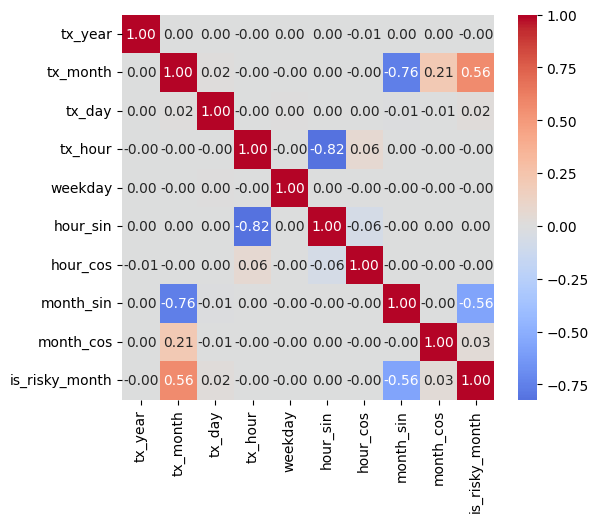

In [38]:
corr = df[TIME_CANDIDATES].corr()

plt.figure(figsize=(6,5))
sns.heatmap(corr, annot=True, fmt=".2f", cmap="coolwarm", center=0)
plt.show()

In [39]:
from statsmodels.stats.outliers_influence import variance_inflation_factor
import statsmodels.api as sm

X = df[TIME_CANDIDATES].dropna()
X = sm.add_constant(X)

vif_df = pd.DataFrame({
    "feature": X.columns,
    "VIF": [variance_inflation_factor(X.values, i) for i in range(X.shape[1])]
})

vif_df

,feature,VIF
0,const,1.422662e+06
1,tx_year,1.000074e+00
2,tx_month,2.834165e+00
3,tx_day,1.000705e+00
4,tx_hour,3.088410e+00
5,weekday,1.000127e+00
6,hour_sin,3.088450e+00
7,hour_cos,1.004591e+00
8,month_sin,2.668642e+00
9,month_cos,1.119327e+00


*VIF = 1/(1-R^2): 어떤 변수가 다른 변수들과 얼마나 겹쳐 있는지(공선성)를 수치화

> sin은 hour와 강하게 겹치지만\
> cos는 거의 겹치지 않는다.

> 심각한 다중공선성 없음

**tx_day 분석: OR=1.0045(선형 약함) → “비선형 패턴(월초/월말)” 확인**

In [40]:
df["day_period"] = pd.cut(
    df["tx_day"],
    bins=[0, 5, 9, 19, 24, 31],
    labels=["월초(1-5)", "초중(6-9)", "월중(10-19)", "중말(20-24)", "월말(25-31)"],
    include_lowest=True
)

day_period_stats = (
    df.groupby("day_period")["fraud"]
      .agg(tx_cnt="count", fraud_cnt="sum", fraud_rate="mean")
      .assign(lift=lambda x: x["fraud_rate"] / base_rate)
)

day_period_stats

/tmp/ipykernel_3298165/1222177100.py:9: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  df.groupby("day_period")["fraud"]


,tx_cnt,fraud_cnt,fraud_rate,lift
day_period,,,,
월초(1-5),85243,1031,0.012095,1.120411
초중(6-9),67414,860,0.012757,1.181751
월중(10-19),168677,2076,0.012308,1.140116
중말(20-24),85400,1061,0.012424,1.150893
월말(25-31),108454,1505,0.013877,1.285489


> 비선형 구조 없음 → 선형 OR(1.005)와 일치 → Drop 확정

In [41]:
df.drop("day_period", axis=1, inplace=True)

| Feature            | Keep / Drop           | 근거 (통계)                                 | 해석 / 모델 관점 판단                         |
| ------------------ | --------------------- | --------------------------------------- | ------------------------------------- |
| **hour_sin**       | ✅ Keep                | OR = 1.66, p ≈ 0, Δ lift +0.295         | 시간 주기성의 주요 축, raw hour 대비 성능 개선 뚜렷    |
| **hour_cos**       | ✅ Keep                | OR = 0.44, p ≈ 0, Δ lift +0.337 (최상위)   | 위상 정보 제공, sin과 결합 시 원형 구조 완성          |
| **weekday**        | ✅ Keep                | OR = 1.07, p ≈ 0, Δ lift +0.081         | 요일 효과 존재, 해석 가능성 및 interaction 확장성 있음 |
| **is_risky_month** | ✅ Keep (보조)           | OR = 1.30, p ≈ 0, Δ lift +0.083         | peak-season 보조 신호, 해석력 강화용            |
| **month_sin**      | ✅ Keep (약한 신호)        | OR = 0.90, p ≈ 0, Δ lift +0.046         | 완만한 계절성 반영, 영향은 제한적                   |
| **tx_hour**        | ❌ Drop                | OR = 0.94, Δ lift +0.127, sin과 상관 -0.82 | 선형 표현 부적절, cyclic encoding이 명확히 우수    |
| **tx_month**       | ❌ Drop                | OR = 1.03, Δ lift +0.040                | raw month 효과 미미, sin/flag로 대체 가능      |
| **month_cos**      | ❌ Drop                | OR ≈ 1.00, p ≈ 0.96, Δ lift ≈ 0         | 설명력 없음                                |
| **tx_year**        | ❌ Drop (모델용) / 분석용 유지 | OR = 0.86, Δ lift +0.109                | 과거-미래 정보 포함 가능성, 운영 모델 직접 사용 부적절      |
| **tx_day**         | ❌ Drop                | OR = 1.005, Δ lift +0.026               | 통계적 유의성은 있으나 실질 영향 거의 없음              |


In [42]:
DROP_FEATURES = [
    "tx_hour",
    "tx_month",
    "tx_day",
    "tx_year",
    "is_online",
    "err_bad_pin",
    "err_bad_zipcode",
    "month_cos"
]

In [43]:
df.columns

Index(['id', 'date', 'client_id', 'card_id', 'amount', 'merchant_id', 'mcc',
       'is_online', 'fraud', 'has_error', 'err_bad_card_number',
       'err_bad_expiration', 'err_bad_cvv', 'err_bad_pin', 'err_bad_zipcode',
       'err_insufficient_balance', 'err_technical_glitch', 'tx_year',
       'tx_month', 'tx_day', 'tx_hour', 'weekday', 'is_refund',
       'log_abs_amount', 'current_age', 'per_capita_income', 'yearly_income',
       'total_debt', 'credit_score', 'num_credit_cards', 'has_chip',
       'num_cards_issued', 'credit_limit', 'year_pin_last_changed',
       'expires_year', 'expires_month', 'months_to_expire', 'is_credit',
       'is_prepaid', 'male', 'cb_Visa', 'cb_Mastercard', 'cb_Amex',
       'cb_Discover', 'months_from_account', 'years_since_pin_change',
       'years_to_retirement', 'income_ratio_region', 'log_yearly_income',
       'log_income_ratio_region', 'abs_amount', 'amount_income_ratio',
       'amount_limit_ratio', 'log_amount_income_ratio',
       'log_amount

In [44]:
df[df["tx_year"]=="2011"]

,id,date,client_id,card_id,amount,merchant_id,mcc,is_online,fraud,has_error,...,amount_limit_ratio,log_amount_income_ratio,log_amount_limit_ratio,month_sin,month_cos,is_risky_month,is_risky_wd_hour,is_risky_hour,hour_sin,hour_cos


In [45]:
df.drop(columns=DROP_FEATURES, inplace=True)

In [46]:
df.columns

Index(['id', 'date', 'client_id', 'card_id', 'amount', 'merchant_id', 'mcc',
       'fraud', 'has_error', 'err_bad_card_number', 'err_bad_expiration',
       'err_bad_cvv', 'err_insufficient_balance', 'err_technical_glitch',
       'weekday', 'is_refund', 'log_abs_amount', 'current_age',
       'per_capita_income', 'yearly_income', 'total_debt', 'credit_score',
       'num_credit_cards', 'has_chip', 'num_cards_issued', 'credit_limit',
       'year_pin_last_changed', 'expires_year', 'expires_month',
       'months_to_expire', 'is_credit', 'is_prepaid', 'male', 'cb_Visa',
       'cb_Mastercard', 'cb_Amex', 'cb_Discover', 'months_from_account',
       'years_since_pin_change', 'years_to_retirement', 'income_ratio_region',
       'log_yearly_income', 'log_income_ratio_region', 'abs_amount',
       'amount_income_ratio', 'amount_limit_ratio', 'log_amount_income_ratio',
       'log_amount_limit_ratio', 'month_sin', 'is_risky_month',
       'is_risky_wd_hour', 'is_risky_hour', 'hour_sin', 'ho

In [47]:
df.to_parquet("data")

# EDA — Time Feature 분석 요약

## 1. 분석 목적 및 대상

거래 시간 정보(`tx_hour`, `weekday`, `tx_month`, `tx_day`, `tx_year`)가 fraud 탐지에 유의미한 신호를 가지는지 검증하고, 최적 인코딩 방식과 파생 피처를 확정한다.

---

## 2. 데이터 정제 — 2011년 제거

분석 전 연도별 fraud rate를 점검한 결과 2011년에서 이상을 발견했다.

| Year | Fraud Rate | Count |
|---|---|---|
| 2010 | 2.57% | 89,944 |
| **2011** | **0.037%** | **93,242** |
| 2012 | 0.70% | 98,782 |
| 2013 | 1.06% | 105,227 |
| 2014 | 0.52% | 107,831 |
| 2015 | 1.63% | 113,404 |

2011년은 거래 건수가 정상 수준임에도 fraud가 단 35건으로 인접 연도 대비 비정상적으로 낮다. **라벨 누락 가능성이 높다**고 판단하여 학습 데이터에서 제외했다. 제거 후 전체 fraud rate = 1.27%로 회복.

---

## 3. 단일 값 컬럼 제거

`is_online`, `err_bad_pin`, `err_bad_zipcode` 세 컬럼이 전체 데이터에서 고유값이 1개임을 확인 → 예측력 없으므로 제거.

---

## 4. Hour 분석

### 4-1. 시간대별 Fraud Rate 패턴

전체 기간 통합 기준 위험 시간대:

| 시간 | Fraud Rate | Lift |
|---|---|---|
| 5시 | 2.30% | 1.82 |
| 3시 | 2.29% | 1.81 |
| 10시 | 2.23% | 1.76 |
| 11시 | 2.14% | 1.69 |
| 12시 | 2.13% | 1.68 |

심야(3~5시)와 오전(10~12시) 두 구간에서 뚜렷한 fraud 스파이크가 존재한다.

### 4-2. Raw vs Cyclic Encoding 비교

`tx_hour`는 0→23이 이어지는 순환 구조인데, raw 정수로 표현하면 선형 모델이 "23시와 0시는 멀다"고 잘못 학습한다. Cyclic encoding(sin/cos)으로 이 문제를 해결할 수 있다.

| 인코딩 방식 | PR_AUC |
|---|---|
| sin + cos | **0.01944** |
| cos only | 0.01785 |
| sin only | 0.01617 |
| raw hour | 0.01510 |

sin+cos 결합이 raw 대비 약 **29% PR_AUC 개선**.

### 4-3. Add-one Δ Lift (Baseline 대비)

| Feature | Δ Lift |
|---|---|
| **hour_cos** | **+0.337** |
| **hour_sin** | **+0.295** |
| tx_hour | +0.127 |

Cyclic encoding이 raw hour보다 모든 metric에서 명확히 우수하다. **raw `tx_hour`는 제거**.

### 4-4. VIF(분산팽창계수) 확인

`hour_sin`은 `tx_hour`와 강하게 겹치지만(VIF ≈ 3.09), `hour_cos`는 거의 겹치지 않는다(VIF ≈ 1.00). 심각한 다중공선성 없음.

---

## 5. is_risky_hour — 극단 시간 binary flag

연속형 sin/cos만으로는 특정 극단 구간의 spike를 충분히 강조하기 어렵다. 이를 보완하기 위해 이진 flag를 추가 생성했다.

다양한 조합 실험 결과:

| 포함 시간 | is_risky=0 fraud rate | is_risky=1 fraud rate |
|---|---|---|
| [3, 4, 5, 9, 10, 11, 12] | 0.00793 | 0.01818 |
| [3, 5, 9, 10, 11] | 0.00871 | 0.01856 |
| [3, 5, 10, 11] | 0.00940 | 0.01882 |
| [3, 5, 10] | 0.01002 | 0.01923 |
| **[3, 5]** | **0.01058** | **0.01967** |

포함 시간이 넓어질수록 non-risky 집단의 fraud rate가 낮아지지만, risky 집단의 농도(contrast)도 함께 희석된다. **Top2(3시, 5시)가 lift 대비 가장 선명한 분리**를 보인다.

> `is_risky_hour = [3, 5]` 채택. Lift ≈ 1.8×.

---

## 6. Weekday 분석

| Metric | 값 |
|---|---|
| OR | 1.07 |
| p-value | < 0.001 |
| Δ Lift | +0.081 |

월요일·금요일·일요일 구간에서 fraud rate가 상대적으로 높다. 통계적으로 유의하며, 시간대(hour)와의 interaction 효과도 확인됐다.

### Weekday × Hour Interaction

히트맵 분석 결과 요일과 시간의 교차 효과가 존재하며, 가장 높은 단일 조합은 **일요일 10시 (Lift ≈ 2.83)**이다.

상위 10개 고위험 (weekday, hour) 조합:

| Weekday | Hour | Fraud Rate |
|---|---|---|
| 6 (일) | 10 | 3.06% |
| 1 (화) | 3 | 2.90% |
| 6 (일) | 5 | 2.86% |
| 4 (금) | 11 | 2.81% |
| 4 (금) | 5 | 2.78% |

이 조합으로 `is_risky_wd_hour` flag를 생성했다. 해당 flag=1 구간 fraud rate = 2.74%(base 대비 Lift ≈ 2.54×).

---

## 7. Month 분석

### 7-1. 월별 Lift

| Month | Fraud Rate | Lift |
|---|---|---|
| 8월 | 1.35% | 1.25 |
| 12월 | 1.29% | 1.19 |
| 10월 | 1.21% | 1.12 |
| 7월 | 1.20% | 1.12 |

거래량은 월별로 거의 균등하여 Lift 차이는 순수하게 fraud 비율 차이에서 비롯된다.

### 7-2. Add-one Δ Lift

| Feature | OR | Δ Lift |
|---|---|---|
| is_risky_month | 1.30 | **+0.083** |
| month_sin | 0.90 | +0.046 |
| tx_month | 1.03 | +0.040 |
| month_cos | 1.00 | **≈ 0** |

`month_cos`는 p-value ≈ 0.96으로 설명력이 전혀 없다. 제거.

`is_risky_month`(7, 8, 10, 12월 flag)가 add-one 기준 최상위이며, `month_sin`은 완만한 계절성을 반영하는 보조 신호로 유지한다.

---

## 8. Day 분석

| Metric | 값 |
|---|---|
| OR | 1.005 |
| Δ Lift | +0.026 |

월중 기간별 분석 결과:

| 구간 | Lift |
|---|---|
| 월초(1-5일) | 1.12 |
| 초중(6-9일) | 1.18 |
| 월중(10-19일) | 1.14 |
| 중말(20-24일) | 1.15 |
| 월말(25-31일) | 1.29 |

OR ≈ 1.005로 통계적으로 유의하지만 실질 영향이 극히 미미하며, 비선형 패턴도 없다. `tx_day` 제거.

---

## 9. Year — Drift 분석

### 9-1. Covariate Drift (PSI)

| Feature | PSI |
|---|---|
| tx_hour | 0.0007 |
| weekday | 0.0006 |

PSI ≈ 0으로 거래 시간 분포 자체는 연도 간 거의 변화 없음. Covariate drift 없다.

### 9-2. Conditional Drift (Lift CV)

일부 시간대에서 연도별 Lift의 CV > 1로 conditional risk가 연도에 따라 변하는 drift가 존재한다. 특히 2011년 이상, 2010년 심야 구간(3~5시) fraud rate 8% 이상은 비정상적이다.

### 9-3. Drift 대응 전략

LightGBM 기반 3가지 방식 비교 결과:

| 방식 | ROC_AUC | PR_AUC |
|---|---|---|
| 전체(2010-2014), no weight | **0.9135** | **0.3410** |
| 최근 4년(2011-2014) | 0.8710 | 0.3246 |
| 전체 + year weight(α=0.8) | 0.8122 | 0.2963 |

> **오래된 데이터가 노이즈가 아니다.** 전체 사용이 최선.
> 현 단계에서 sliding window나 aggressive weighting은 불필요.

`tx_year`는 운영 모델에 직접 사용 부적절(과거-미래 정보 혼재). **제거**.

---

## 10. 최종 피처 결정

### ✅ KEEP

| Feature | 역할 | 근거 |
|---|---|---|
| `hour_sin` | 시간 주기성 (위상 축 1) | OR=1.69, Δ Lift +0.295, PR_AUC 개선 뚜렷 |
| `hour_cos` | 시간 주기성 (위상 축 2) | OR=0.42, Δ Lift +0.337 (시간 피처 중 최상위) |
| `is_risky_hour` | 심야 극단 시간 flag | Top2(3, 5시) 기준, Lift ≈ 1.8× |
| `weekday` | 요일 효과 | OR=1.07, Δ Lift +0.081, hour와 interaction |
| `is_risky_wd_hour` | 요일 × 시간 고위험 조합 flag | 상위 10개 조합, Lift ≈ 2.54× |
| `month_sin` | 완만한 계절성 | Δ Lift +0.046, 약하지만 유의 |
| `is_risky_month` | 성수기 flag | 7,8,10,12월, Δ Lift +0.083 |

### ❌ DROP

| Feature | 사유 |
|---|---|
| `tx_hour` | Cyclic encoding으로 완전 대체. raw 선형 표현 부적절 |
| `tx_month` | `is_risky_month` + `month_sin`으로 대체. raw 효과 미미 |
| `month_cos` | OR ≈ 1.00, p ≈ 0.96. 설명력 없음 |
| `tx_day` | OR ≈ 1.005, Δ Lift +0.026. 실질 영향 미미 |
| `tx_year` | 운영 모델 직접 사용 부적절. 과거-미래 정보 혼재 가능성 |
| `is_online` | 단일 값 컬럼 (분산 없음) |
| `err_bad_pin` | 단일 값 컬럼 (분산 없음) |
| `err_bad_zipcode` | 단일 값 컬럼 (분산 없음) |
| `2011년 데이터` | fraud rate 0.037% — 라벨 누락 의심, 학습 제외 |

---

## 11. 최종 Time Feature Set 요약

| Category | Feature | 비고 |
|---|---|---|
| Hour (Cyclic) | `hour_sin`, `hour_cos` | 주기 구조 완전 표현 |
| Hour (Extreme) | `is_risky_hour` | [3, 5]시 binary flag |
| Weekday | `weekday` | 요일 효과 직접 사용 |
| Weekday × Hour | `is_risky_wd_hour` | 상위 10개 고위험 조합 flag |
| Month (Cyclic) | `month_sin` | 완만한 계절성 반영 |
| Month (Extreme) | `is_risky_month` | [7, 8, 10, 12]월 binary flag |